In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

In [3]:
X_train = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/X_train_processed.csv')
X_test = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/X_test_processed.csv')
y = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/y_train.csv').squeeze() # pandas series
test = pd.read_csv("/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/test.csv")
test_ID = test['Id']

In [4]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y: {y.shape}")

X_train: (1456, 238)
X_test: (1459, 238)
y: (1456,)


In [5]:
# Evaluation Function
def rmse_cv(model, X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    rmse = -cross_val_score(
        model, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    
    return rmse

In [ ]:
results = {}

def evaluate_model(name, model, X, y):
    scores = rmse_cv(model, X, y)
    results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name:20s} RMSE: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

In [7]:
# models pipeline
# RobustScaler is better than StandardScaler for data with outliers
# It uses median and IQR instead of mean and std
# Ridge Regression --->linear models
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Ridge(alpha=10))
])
evaluate_model('Ridge', ridge, X_train, y)


Ridge                RMSE: 0.1119 ± 0.0081


array([0.11654088, 0.11159949, 0.11861653, 0.11630135, 0.09644245])

In [8]:
# Lasso Regression --->linear models
lasso = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Lasso(alpha=0.0005, max_iter=10000))
])
evaluate_model('Lasso', lasso, X_train, y)

Lasso                RMSE: 0.1119 ± 0.0072


array([0.11668723, 0.11267296, 0.11920714, 0.11233953, 0.09842087])

In [9]:
# ElasticNet --->linear models
elasticnet = Pipeline([
    ('scaler', RobustScaler()),
    ('model', ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000))
])
evaluate_model('ElasticNet', elasticnet, X_train, y)

ElasticNet           RMSE: 0.1118 ± 0.0071


array([0.11647124, 0.11284248, 0.11910757, 0.11217815, 0.09848414])

In [10]:
# Random Forest --->Tree Models 
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
evaluate_model('Random Forest', rf, X_train, y)

Random Forest        RMSE: 0.1354 ± 0.0128


array([0.14215738, 0.12491425, 0.14697385, 0.14731462, 0.11566652])

In [11]:
# XGBoost --->Tree Models 
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
evaluate_model('XGBoost', xgb_model, X_train, y)

XGBoost              RMSE: 0.1207 ± 0.0120


array([0.12830488, 0.11254809, 0.13253211, 0.12904188, 0.10112233])

In [12]:
# LightGBM --->Tree Models 
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
evaluate_model('LightGBM', lgb_model, X_train, y)

LightGBM             RMSE: 0.1233 ± 0.0132


array([0.13279828, 0.11567752, 0.13361249, 0.13382856, 0.10077656])

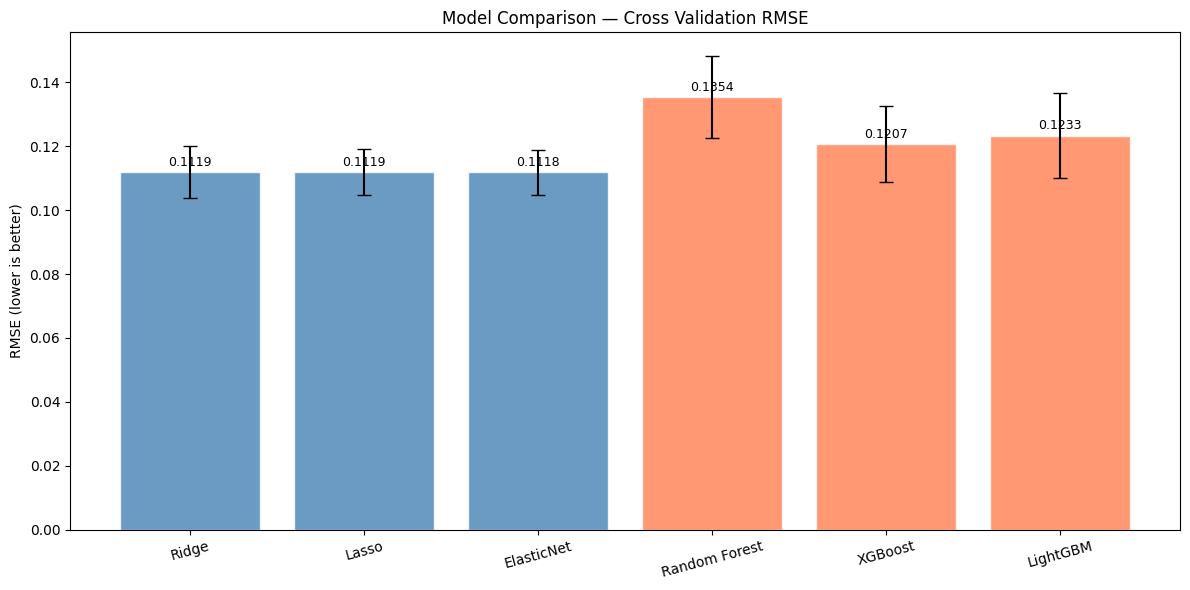

In [13]:
#Models Comparison Plot

plt.figure(figsize=(12, 6))

names = list(results.keys())
means = [results[m]['mean'] for m in names]
stds = [results[m]['std'] for m in names]

colors = ['steelblue', 'steelblue', 'steelblue',
          'coral', 'coral', 'coral']

bars = plt.bar(names, means, yerr=stds, capsize=5,
               color=colors, edgecolor='white', alpha=0.8)

plt.ylabel('RMSE (lower is better)')
plt.title('Model Comparison — Cross Validation RMSE')
plt.xticks(rotation=15)

# Add value labels on bars
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{mean:.4f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Stacking Ensemble

estimators = [
    ('ridge', Pipeline([('scaler', RobustScaler()),
                        ('model', Ridge(alpha=10))])),
    ('lasso', Pipeline([('scaler', RobustScaler()),
                        ('model', Lasso(alpha=0.0005, max_iter=10000))])),
    ('xgb',   xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, subsample=0.8,
                                 colsample_bytree=0.8, random_state=42,
                                 n_jobs=-1)),
    ('lgb',   lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                  max_depth=4, num_leaves=31,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, n_jobs=-1, verbose=-1))
]

# Ridge as meta-model — simple and prevents overfitting
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1
)

evaluate_model('Stacking', stacking, X_train, y)

Stacking             RMSE: 0.1109 ± 0.0105


array([0.11734803, 0.10678894, 0.12145975, 0.11651303, 0.09231812])

In [ ]:
# Train best models on full training data
print("Training final models...")

# Train all base models
ridge.fit(X_train, y)
lasso.fit(X_train, y)
xgb_model.fit(X_train, y)
lgb_model.fit(X_train, y)
stacking.fit(X_train, y)

# Weighted average ensemble — blend predictions
ridge_pred    = ridge.predict(X_test)
lasso_pred    = lasso.predict(X_test)
xgb_pred      = xgb_model.predict(X_test)
lgb_pred      = lgb_model.predict(X_test)
stacking_pred = stacking.predict(X_test)

# Weighted blend — give more weight to better models
final_pred = (0.1 * ridge_pred +
              0.1 * lasso_pred +
              0.3 * xgb_pred +
              0.3 * lgb_pred +
              0.2 * stacking_pred)

# Convert back from log scale
final_pred_prices = np.expm1(final_pred)

# submission file
submission = pd.DataFrame({
    'Id': test_ID,
    'SalePrice': final_pred_prices
})

submission.to_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/submission.csv', index=False)
print("Submission file created")
print(submission.describe())

Training final models...
Submission file created
                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  178114.000609
std     421.321334   77578.740653
min    1461.000000   43598.959471
25%    1825.500000  126915.803432
50%    2190.000000  156610.054788
75%    2554.500000  209644.929320
max    2919.000000  690150.088923
